# 🏁 Análise Completa — GP da Áustria 2026

Estudo de caso usando a biblioteca `funcoes_telemetria.py` construída 
nos Módulos 1 e 2, aplicada a uma corrida real e recente.

**Contexto:** George Russell venceu, sua 7ª vitória na carreira, na 
frente de Verstappen e Antonelli (líder do campeonato). Destaque para 
abandonos de Sergio Pérez e Valtteri Bottas (Cadillac) por 
superaquecimento dos freios — ótimo gancho para testar nossa análise 
de energia de frenagem.

In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import fastf1
import fastf1.plotting
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

os.makedirs('../cache', exist_ok=True)
fastf1.Cache.enable_cache('../cache')

from funcoes_telemetria import (
    comparar_pilotos, encontrar_ponto_na_pista, mapa_velocidade,
    comparar_mapas_velocidade, analisar_stints, obter_dados_corrida,
    comparar_stints, ranking_sessao, calcular_g_longitudinal, calcular_g_lateral,
    diagrama_gg, calcular_energia_frenagem, mapa_energia_frenagem
)

print("Funções importadas com sucesso!")

Funções importadas com sucesso!


In [2]:
session_r = fastf1.get_session(2026, 'Austria', 'R')
session_r.load()

print("Corrida da Áustria carregada!")

core           INFO 	Loading data for Austrian Grand Prix - Race [v3.8.3]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No c

Corrida da Áustria carregada!


## 📊 Classificação

George Russell fez a pole, com Verstappen batendo no fim da Q3 
(largou em P5). Vamos ver o ranking completo.

core           INFO 	Loading data for Austrian Grand Prix - Qualifying [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 22 drivers: ['63', '16', '44', '12', '3', '1', '81', '6', '30', '41', '10', '5', '87', '27', '31', '43', '55', '23', '11', '77', '14', '18']
req            INFO 	Using cached data for driver_info


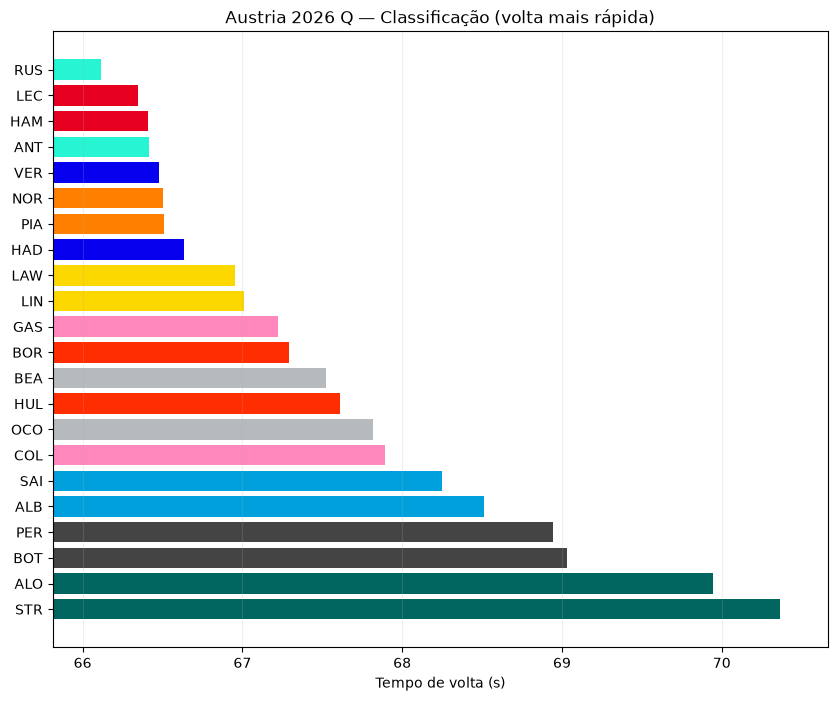

In [3]:
ranking_austria = ranking_sessao(2026, 'Austria', 'Q')

# Análise do duelo entre Russel e Verstappen

core           INFO 	Loading data for Austrian Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Driver 63 completed the race distance 00:00.530000 before the recorded end of the session.
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 22 drivers: ['63', '3', '12', '81', '44', '6', '1', '16', '30', '41', '5', '27

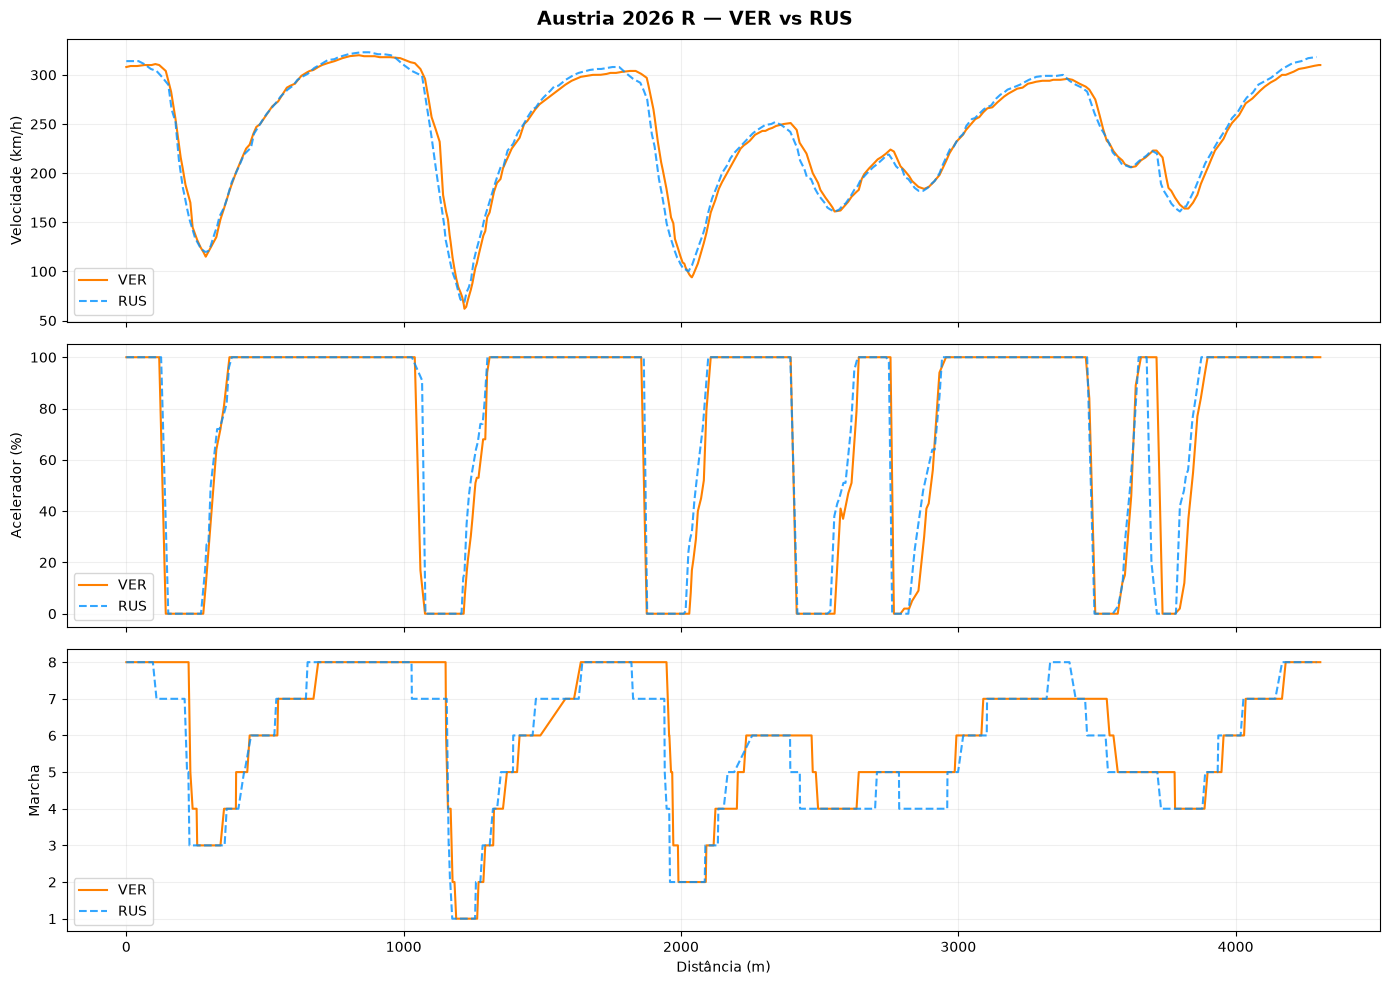

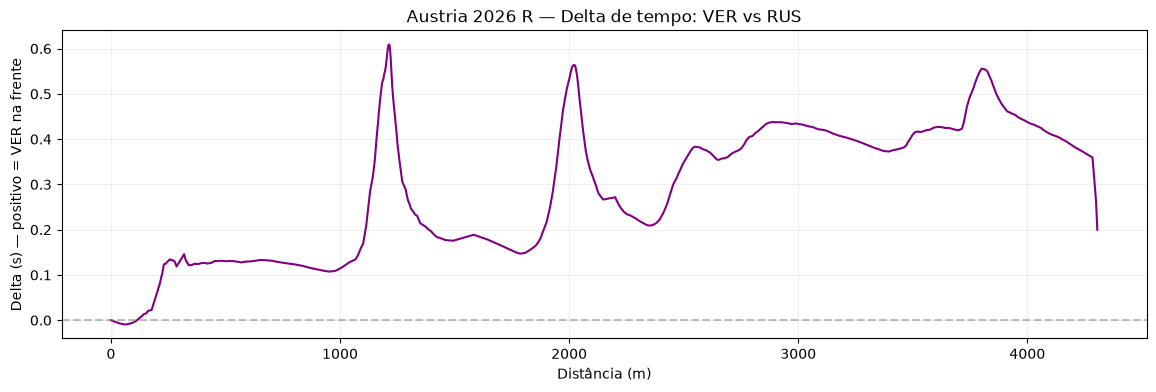

In [4]:
tel_ver, tel_rus = comparar_pilotos(2026, 'Austria', 'R', 'VER', 'RUS')

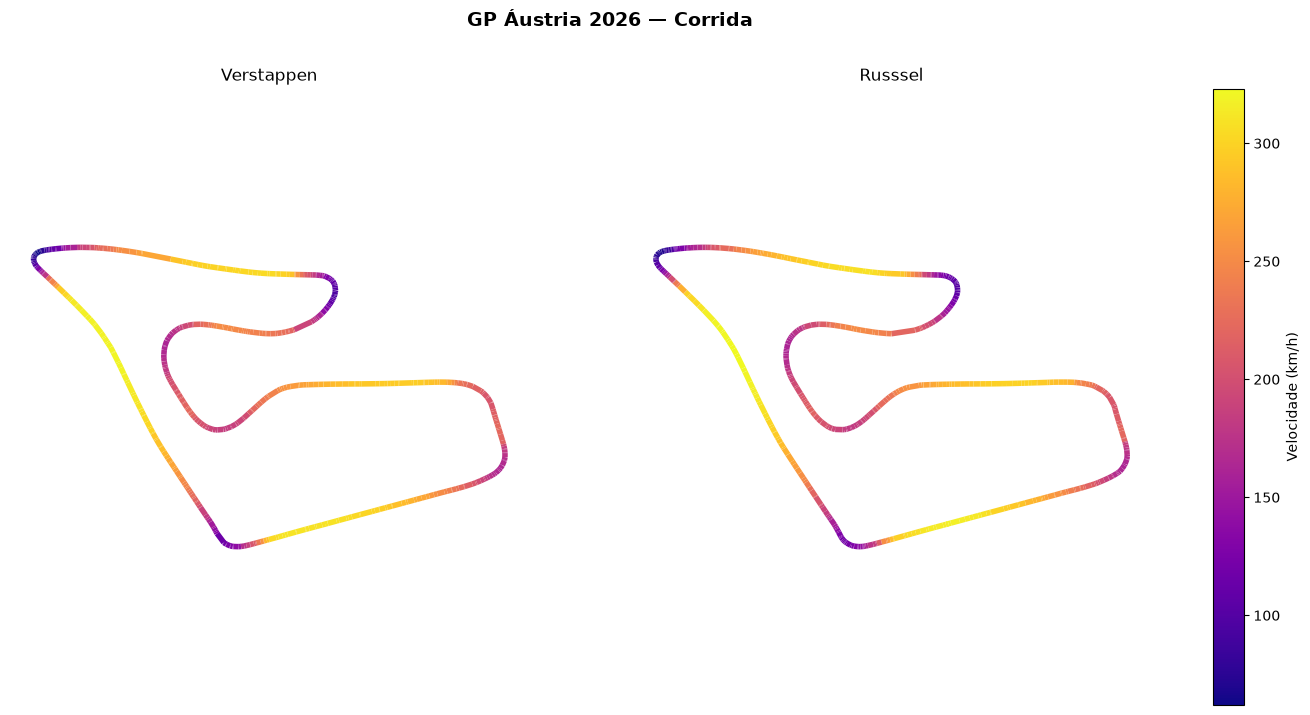

In [5]:
comparar_mapas_velocidade(tel_ver, tel_rus, 'Verstappen', 'Russsel', 
                            titulo_geral='GP Áustria 2026 — Corrida')

core           INFO 	Loading data for Austrian Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Driver 63 completed the race distance 00:00.530000 before the recorded end of the session.
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 22 drivers: ['63', '3', '12', '81', '44', '6', '1', '16', '30', '41', '5', '27

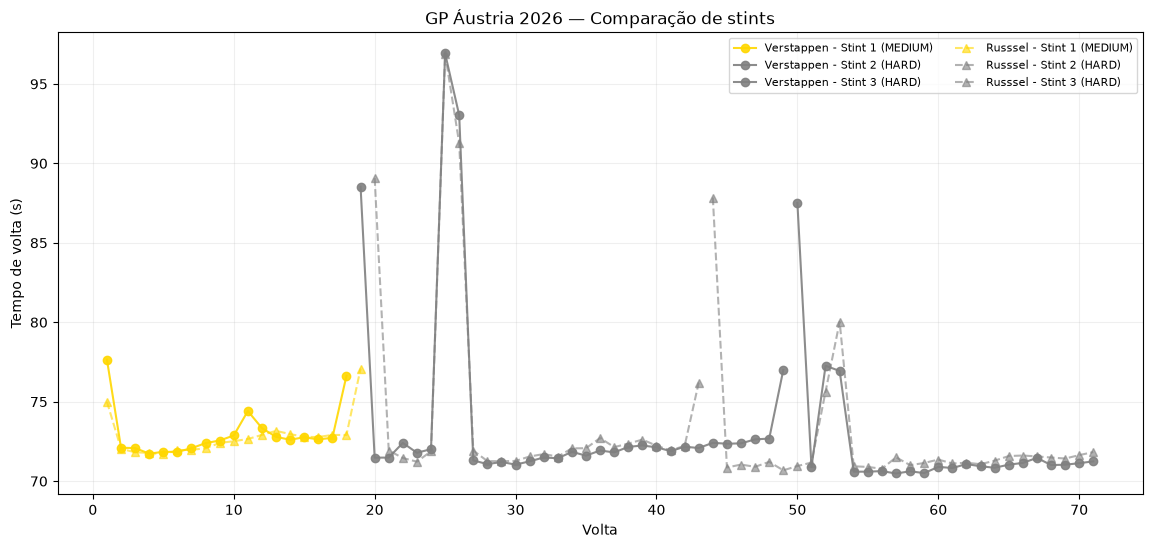

In [6]:
voltas_ver2 = obter_dados_corrida(2026, 'Austria', 'VER')
voltas_rus2 = obter_dados_corrida(2026, 'Austria', 'RUS')

comparar_stints(voltas_ver2, voltas_rus2, 'Verstappen', 'Russsel',
                 titulo='GP Áustria 2026 — Comparação de stints')